# Prediction of Carbonation Depth in Reinforced Concrete Structures using Machine Learning

Carbonation is a major cause of reinforcement corrosion in concrete structures. It is a chemical process where carbon dioxide ($CO_2$) from the atmosphere penetrates the concrete and reacts with calcium hydroxide, reducing the pH and depassivating the steel reinforcement.
This notebook aims to develop and compare Machine Learning (ML) models to predict the **Carbonation Depth ($x$)** based on environmental and material parameters.

 **Key Variables (Features):**
* $w/c$: Water-to-cement ratio
* $f_{ck}$: Concrete compressive strength (MPa)
* $RH$: Relative Humidity (%)
* $CO_2$: $CO_2$ concentration (%)
* $t$: Time of exposure (years)
* **Target ($y$):** Carbonation Depth (mm) 

Before running the notebook, you need to install the following libraries.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt



## 1. Data Loading and Exploration
Loading the experimental dataset containing carbonation depth meansurements and influence factors.

In [3]:
# Loading the dataset
df = pd.read_excel('rccarbonation.xlsx')

# Displaying dataset information
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nFirst rows:")

# Showing the dataframe
display(df)

Shape: (20000, 7)
Columns: ['CCO₂ (%)', 'fc (MPa)', 'RH (%)', 'Type of cement', 'Exposure conditions', 't (years)', 'Possan']

First rows:


,CCO₂ (%),fc (MPa),RH (%),Type of cement,Exposure conditions,t (years),Possan
0,0.08,25.9,35.4,CPII Z,PIA,9,10.1384
1,0.07,21.7,43.8,CPV - ARI,UEA,92,23.2231
2,0.08,30.3,83.7,CPIV,UEA,58,13.2715
3,0.15,22.8,37.6,CPIV,PIA,42,45.1498
4,0.03,26.4,65.2,CPII F,UEA,96,22.6178
...,...,...,...,...,...,...,...
19995,0.19,39.2,43.6,CPII Z,PIA,91,23.9632
19996,0.15,45.0,35.3,CPII F,PIA,26,7.5256
19997,0.28,36.0,42.9,CPIV,PIA,87,34.9459
19998,0.16,34.1,84.9,CPV - ARI,PEA,27,5.5076


### 1.1. Handling Categorical Variables
The dataset contains categorical features: **'Exposure conditions'** and **'Types of cement'**. Since most machine leraning algorithms require numerical input, threse text labels must be encoded into integers. 

In this step, we:
1. Identify the unique categories in each column
2. Map each category to a specific numeric value 

In [4]:
# 1. Analyzing 'Exposure conditions'
unique_exposure_conditions = (
    df['Exposure conditions']  # Select column 
    .astype(str)               # Ensure data type
    .unique()                  # Get unique values
)
num_unique_exposure = len(unique_exposure_conditions)

print(f"Number of distinct values (Exposure): {num_unique_exposure}")
print(f"Values: {unique_exposure_conditions}")
print("--------------------------------------------------")

# 2. Analyzing 'Type of cement'
unique_cement_types = (
    df['Type of cement']  # Select column
    .astype(str)          # Ensure data type is string
    .unique()             # Get unique values
)
num_unique_cement = len(unique_cement_types)

print(f"Number of distinct values (Cement): {num_unique_cement}")
print(f"Values: {unique_cement_types}")

# 3. Defining the mapping dictionary (Text => Number) 
# Using regex boundaries (\b) to ensure exact matches
mapping_dict = {
    r'\bPIA\b': '0',
    r'\bUEA\b': '1',
    r'\bPEA\b': '2',
    r'\bCPII Z\b': '0',
    r'\bCPV - ARI\b': '1',
    r'\bCPIV\b': '2',
    r'\bCPII F\b': '3',
    r'\bCPIII\b': '4',
    r'\bCPII E\b': '5',
}

# 4. Applying the mapping to the dataframe
df[['Exposure conditions','Type of cement']] = df[['Exposure conditions','Type of cement']].replace(mapping_dict, regex=True)

# Displaying the updated dataframe
display(df)

Number of distinct values (Exposure): 3
Values: ['PIA ' 'UEA ' 'PEA ']
--------------------------------------------------
Number of distinct values (Cement): 6
Values: ['CPII Z' 'CPV - ARI' 'CPIV' 'CPII F' 'CPIII' 'CPII E']


,CCO₂ (%),fc (MPa),RH (%),Type of cement,Exposure conditions,t (years),Possan
0,0.08,25.9,35.4,0,0,9,10.1384
1,0.07,21.7,43.8,1,1,92,23.2231
2,0.08,30.3,83.7,2,1,58,13.2715
3,0.15,22.8,37.6,2,0,42,45.1498
4,0.03,26.4,65.2,3,1,96,22.6178
...,...,...,...,...,...,...,...
19995,0.19,39.2,43.6,0,0,91,23.9632
19996,0.15,45.0,35.3,3,0,26,7.5256
19997,0.28,36.0,42.9,2,0,87,34.9459
19998,0.16,34.1,84.9,1,2,27,5.5076


## 2. Automated Training and Prediction Pipeline

To streamline the analysis and simulate different scenarios, we implemented a unified function named `predict_carbonation`. This function encapsulates the entire Machine Learning workflow, ensuring that the best model is selected dynamically for each simulation.

In [11]:
def predict_carbonation(CCO2, fc, RH, type_of_cement, exposure_conditions, time_list):
    """
    Generates carbonation predictions for a list of time steps.
    
    Parameters:
    - CCO2: CO2 content (%)
    - fc: Concrete compressive strength (MPa)
    - RH: Relative humidity (%)
    - type_of_cement: Type of cement (string)
    - exposure_conditions: Exposure conditions (string)
    - time_list: List of time steps (in years) to predict
    
    Returns:
    - DataFrame containing time steps and predictions
    """
    
    # Defining Features (X) and Target (y)
    # Note: 'Possan' seems to be the target column in the original dataframe
    # We do this inside the function to ensure fresh split, but typically this could be outside.
    X = df.drop('Possan', axis=1)
    y = df['Possan']
    
    # Splitting the dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"Training set size: {len(X_train)} samples")
    print(f"Test set size: {len(X_test)} samples")
    # print(X_train.shape, X_test.shape)

    # Dictionary of models to be evaluated
    models = {
        "LinearRegression": LinearRegression(),
        "Ridge": Ridge(),
        "Lasso": Lasso(),
        "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
        "RandomForestRegressor": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42),
        "HistGradientBoostingRegressor": HistGradientBoostingRegressor(random_state=42),
    }

    # Dictionary to store performance metrics
    results = {}

    # 1. Training and Evaluating all models
    for name, model in models.items():
        model.fit(X_train, y_train)          # Train the model
        y_pred = model.predict(X_test)       # Predict on test set
        r2 = r2_score(y_test, y_pred)        # Calculate R2 score
        results[name] = r2                   # Store result
        print(f"{name}: R² = {r2:.4f}")

    # 2. Selecting the Best Model
    best_model_name = max(results, key=results.get)
    best_r2 = results[best_model_name]
    best_model = models[best_model_name]

    print("\nBest model found:")
    print(f"{best_model_name} with R² = {best_r2:.4f}")

    # 3. Constructing Input DataFrame for Prediction (Scenario Simulation)
    pred_rows = []
    for t in time_list:
        pred_rows.append({
            'CCO₂ (%)': CCO2,
            'fc (MPa)': fc,
            'RH (%)': RH,
            'Type of cement': type_of_cement,
            'Exposure conditions': exposure_conditions,
            't (years)': t
        })
    pred_input_df = pd.DataFrame(pred_rows)

    # Align columns with X_train structure (filling missing ones with NaN if necessary)
    for col in X_train.columns:
        if col not in pred_input_df.columns:
            pred_input_df[col] = np.nan
    pred_input_df = pred_input_df[X_train.columns]

    # 4. Generating Predictions
    # Using try-except to handle potential errors during prediction
    try:
        preds = best_model.predict(pred_input_df)
    except Exception:
        preds = np.full(len(time_list), np.nan)

    # Creating the final results DataFrame
    results_df = pd.DataFrame({
        "Time (years)": time_list,
        "Predicted Carbonation (mm)": preds
    })
    
    return results_df

## 3. Model Evaluation 
Assessing the model's accuracy using statistical metrics:
* **$R^2$ (Coefficient of Determination):** Represents the porportion of variance in the target variable explained by the model. (Close to 1 is better)

In [12]:
# Lista de tempos
time_list = [1, 5, 10, 20, 30, 40, 45, 50, 55, 60, 80, 100]
#teste baseando na segunda linha do dataframe original
results_df = predict_carbonation(
    CCO2 = 0.28,
    fc = 36.0,        # Resistência do concreto (MPa)
    RH = 42.9,        # Umidade relativa (%)
    type_of_cement = "2",          # Tipo de cimento
    exposure_conditions = "0" ,       # Condições de exposição
    time_list=time_list
)


Training set size: 16000 samples
Test set size: 4000 samples
LinearRegression: R² = 0.5505
Ridge: R² = 0.5505
Lasso: R² = 0.5363
DecisionTreeRegressor: R² = 0.9143
RandomForestRegressor: R² = 0.9583
GradientBoostingRegressor: R² = 0.9468
HistGradientBoostingRegressor: R² = 0.9922

Best model found:
HistGradientBoostingRegressor with R² = 0.9922


### 3.1. Reference Guide: Input Variable Encoding

To simulate scenarios using the `predict_carbonation` function, categorical variables must be entered using their corresponding numerical codes. Please refer to the mapping below:

#### **A. Type of Cement**
| Code | Description |
| :---: | :--- |
| **0** | CPII Z |
| **1** | CPV - ARI |
| **2** | CPIV |
| **3** | CPII F |
| **4** | CPIII |
| **5** | CPII E |

#### **B. Exposure Conditions**
| Code | Description |
| :---: | :--- |
| **0** | PIA (Internal Protected) |
| **1** | UEA (External Unprotected) |
| **2** | PEA (External Protected) |

In [19]:
display(results_df)

,Tempo (anos),Carbonatação Prevista (mm)
0,1,4.839728
1,5,8.585119
2,10,11.407207
3,20,15.784207
4,30,20.334861
5,40,23.435802
6,45,25.796739
7,50,28.017446
8,55,28.101974
9,60,30.027801


## 4. Plot Time vs Carbonation


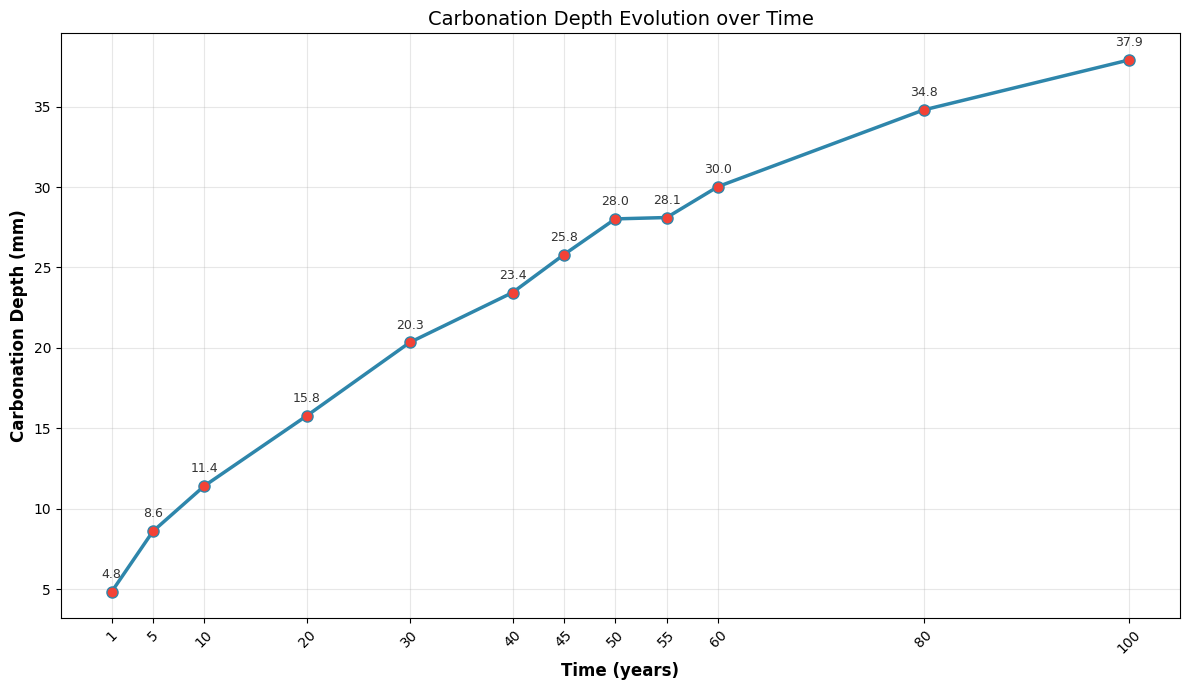

In [13]:
# Plotting Time vs. Carbonation Depth
plt.figure(figsize=(12, 7))

# Main Plot
# Note: Using column names in English as defined in the prediction function
plt.plot(
    results_df['Time (years)'], 
    results_df['Predicted Carbonation (mm)'],
    marker='o', 
    linewidth=2.5, 
    markersize=8, 
    color='#2E86AB', 
    markerfacecolor='#F24236'
)

# Graph Customization
plt.xlabel('Time (years)', fontsize=12, fontweight='bold')
plt.ylabel('Carbonation Depth (mm)', fontsize=12, fontweight='bold')
plt.title('Carbonation Depth Evolution over Time', fontsize=14)

plt.grid(True, alpha=0.3)
plt.xticks(time_list, rotation=45)

# Adding values (annotations) to data points
for i, row in results_df.iterrows():
    plt.annotate(
        f'{row["Predicted Carbonation (mm)"]:.1f}',
        (row['Time (years)'], row['Predicted Carbonation (mm)']),
        textcoords="offset points", 
        xytext=(0, 10), 
        ha='center',
        fontsize=9, 
        alpha=0.8
    )

plt.tight_layout()
plt.show()